# **Handling Imbalanced Datasets**

An imbalanced dataset occurs when one class has significantly more samples than another. This is common in fraud detection, disease diagnosis, spam detection, and anomaly detection.

## Why Is It a Problem?

### Example

| Class | Count |
|---------|---------|
| No Fraud | 9,900 |
| Fraud | 100 |

A model predicting **"No Fraud"** for every case achieves:

Accuracy = 9900 / 10000 = 99%

Although accuracy is high, the model completely fails to identify fraud cases.

---

## Techniques for Handling Imbalanced Data

### 1. Random Undersampling

Reduce the number of samples in the majority class.

#### Before

| Class | Count |
|---------|---------|
| Majority | 10,000 |
| Minority | 500 |

#### After

| Class | Count |
|---------|---------|
| Majority | 500 |
| Minority | 500 |

#### Pros
- Faster training
- Reduces dataset size

#### Cons
- Loss of valuable information
- Can lead to underfitting

---

### 2. Random Oversampling

Duplicate samples from the minority class.

#### Before

| Class | Count |
|---------|---------|
| Majority | 10,000 |
| Minority | 500 |

#### After

| Class | Count |
|---------|---------|
| Majority | 10,000 |
| Minority | 10,000 |

#### Pros
- No data loss
- Simple implementation

#### Cons
- Risk of overfitting
- Repeated observations

---

### 3. SMOTE (Synthetic Minority Oversampling Technique)

Creates synthetic minority samples instead of duplicating existing ones.

#### How It Works
1. Select a minority sample.
2. Find its nearest neighbors.
3. Generate new points between them.

#### Pros
- Reduces overfitting
- Produces realistic synthetic samples

#### Cons
- May generate noisy samples
- Less effective with highly complex distributions

---

### 4. ADASYN (Adaptive Synthetic Sampling)

An extension of SMOTE that generates more synthetic samples in difficult regions.

#### Pros
- Focuses on hard-to-learn examples
- Improves minority class learning

#### Cons
- Can amplify noise

---

### 5. Class Weighting

Assign higher penalties to mistakes on minority-class predictions.

#### Example

```python
model = LogisticRegression(class_weight="balanced")
```

#### Pros
- No data modification
- Works well with many algorithms

#### Cons
- May not fully solve severe imbalance

---

### 6. Ensemble Methods

Use multiple models to improve minority-class detection.

#### Popular Techniques
- Balanced Random Forest
- EasyEnsemble
- XGBoost with class weights
- LightGBM with scale_pos_weight

#### Pros
- High performance
- Robust predictions

#### Cons
- Increased computational cost

---

## Evaluation Metrics for Imbalanced Data

### Avoid Using Accuracy Alone

Accuracy can be misleading.

### Preferred Metrics

#### Precision

```text
Precision = TP / (TP + FP)
```

Measures how many predicted positives are actually positive.

---

#### Recall

```text
Recall = TP / (TP + FN)
```

Measures how many actual positives are correctly identified.

---

#### F1 Score

```text
F1 = 2 × (Precision × Recall) / (Precision + Recall)
```

Balances Precision and Recall.

---

#### ROC-AUC

Measures model performance across different thresholds.

---

#### PR-AUC (Precision-Recall AUC)

Often more informative than ROC-AUC for highly imbalanced datasets.

---

## Best Practices

1. Use Stratified Train-Test Split.
2. Evaluate with Precision, Recall, and F1-score.
3. Apply SMOTE only on training data.
4. Try class weighting before resampling.
5. Use ensemble methods for highly imbalanced datasets.
6. Monitor overfitting when oversampling.

---

## Comparison Table

| Method | Data Loss | Overfitting Risk | Complexity |
|----------|----------|----------|----------|
| Random Undersampling | High | Low | Easy |
| Random Oversampling | None | High | Easy |
| SMOTE | None | Medium | Moderate |
| ADASYN | None | Medium | Moderate |
| Class Weighting | None | Low | Easy |
| Ensemble Methods | None | Low | High |

---

## Memory Trick

- **Undersampling** → Remove majority samples.
- **Oversampling** → Duplicate minority samples.
- **SMOTE** → Create synthetic minority samples.
- **ADASYN** → Create more samples in difficult regions.
- **Class Weights** → Penalize minority-class mistakes more heavily.
- **Ensemble Methods** → Combine multiple models for better balance.

In [2]:
## Oversampling / Upsampling

import pandas as pd

# Create an imbalanced dataset
df = pd.DataFrame({
    'amount': [100, 200, 150, 300, 250, 180, 120, 400, 350, 220, 500, 600],
    'target': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1]
})

print("Before Oversampling:")
print(df['target'].value_counts())

# Separate majority and minority classes
majority = df[df['target'] == 0]
minority = df[df['target'] == 1]

# Oversample minority class
minority_upsampled = minority.sample(
    n=len(majority),  # make minority size equal to majority size
    replace=True,
    random_state=42
)

# Combine majority class with oversampled minority class
df_oversampled = pd.concat([majority, minority_upsampled])

print("\nAfter Oversampling:")
print(df_oversampled['target'].value_counts())

Before Oversampling:
target
0    10
1     2
Name: count, dtype: int64

After Oversampling:
target
0    10
1    10
Name: count, dtype: int64


In [4]:
## Undersampling / Downsampling

import pandas as pd

# Separate majority and minority classes
majority = df[df['target'] == 0]
minority = df[df['target'] == 1]

# Undersample majority class
majority_downsampled = majority.sample(
    n=len(minority),
    random_state=42
)

# Combine
df_undersampled = pd.concat([majority_downsampled, minority])

print("\nAfter Undersampling:")
print(df_undersampled['target'].value_counts())


After Undersampling:
target
0    2
1    2
Name: count, dtype: int64


### **Realistic example**

In [ ]:
from sklearn.utils import resample
import pandas as pd
import numpy as np

amounts = (
    list(np.random.randint(100, 1000, 9900)) +
    list(np.random.randint(5000, 10000, 100))
)

# Create imbalanced dataset
df = pd.DataFrame({
    'amount': amounts,
    'target': [0]*9900 + [1]*100        # [0,0,0,0,.....,1,1,1]
})

print("Before Oversampling:")
print(df['target'].value_counts())

# Separate classes
majority = df[df['target'] == 0]
minority = df[df['target'] == 1]

# Oversample minority class
minority_upsampled = resample(
    minority,
    replace=True,              # sample with replacement
    n_samples=len(majority),   # 9900 samples
    random_state=42
)

# Combine
df_oversampled = pd.concat([majority, minority_upsampled])

print("\nAfter Oversampling:")
print(df_oversampled['target'].value_counts())

Before Oversampling:
target
0    9900
1     100
Name: count, dtype: int64

After Oversampling:
target
0    9900
1    9900
Name: count, dtype: int64


In [10]:
minority_upsampled.head()

,amount,target
9951,6067,1
9992,8134,1
9914,7724,1
9971,6892,1
9960,6800,1


In [11]:
pd.concat([majority, minority_upsampled])

,amount,target
0,570,0
1,122,0
2,989,0
3,446,0
4,844,0
...,...,...
9948,6324,1
9988,9999,1
9910,9929,1
9961,6648,1


In [8]:
from sklearn.utils import resample

# Separate classes
majority = df[df['target'] == 0]
minority = df[df['target'] == 1]

# Downsample majority class
majority_downsampled = resample(
    majority,
    replace=False,            # no duplication
    n_samples=len(minority),  # 100 samples
    random_state=42
)

# Combine
df_undersampled = pd.concat([majority_downsampled, minority])

print("\nAfter Downsampling:")
print(df_undersampled['target'].value_counts())


After Downsampling:
target
0    100
1    100
Name: count, dtype: int64


In [12]:
majority_downsampled.head()

,amount,target
8432,189,0
5680,183,0
4767,769,0
9218,822,0
621,490,0


## **Handling Imbalanced Dataset by SMOTE**

In [14]:
from sklearn.datasets import make_classification

In [15]:
x,y=make_classification(n_samples=10000,n_redundant=0,n_features=2,n_clusters_per_class=1,weights=[.875],random_state=12)

In [16]:
import pandas as pd 
df1=pd.DataFrame(x,columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['target'])
final_df = pd.concat([df1,df2],axis=1)
final_df.head()

,f1,f2,target
0,1.029600,-1.235937,0
1,-0.735233,-1.094894,0
2,-0.007200,-1.127353,0
3,-1.228777,-1.094613,0
4,-1.429518,-1.183838,0


In [17]:
final_df['target'].value_counts()

target
0    8712
1    1288
Name: count, dtype: int64

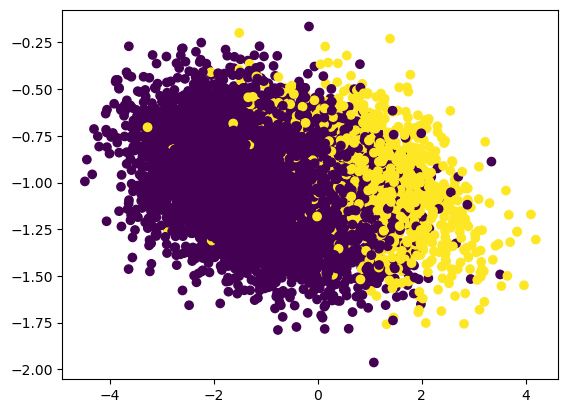

In [18]:
import matplotlib.pyplot as plt 
plt.scatter(final_df['f1'],final_df['f2'],c = final_df['target'])

In [19]:
from imblearn.over_sampling import SMOTE

In [23]:
## transform the dataset
oversample = SMOTE()
x,y=oversample.fit_resample(final_df[['f1','f2']],final_df['target'])

In [25]:
x.shape

(17424, 2)

In [28]:
len(y[y==0])

8712

In [29]:
len(y[y==1])

8712

In [32]:
df1=pd.DataFrame(x,columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['target'])
df_oversampled = pd.concat([df1,df2],axis=1)

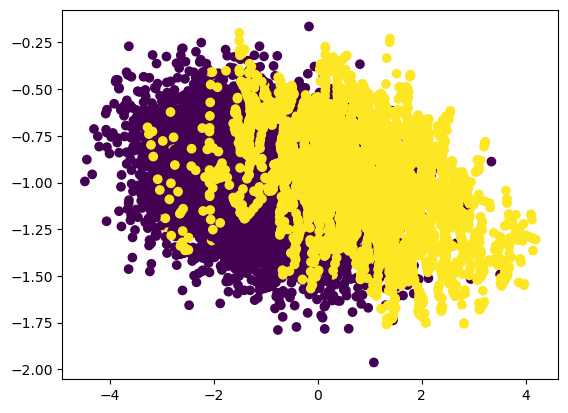

In [33]:
plt.scatter(df_oversampled['f1'],df_oversampled['f2'],c = df_oversampled['target'])